# Data efficiency across two saved training-subset selections

**Stage 5 scientific report.** This notebook asks whether the validation patterns observed from 25 to 500 labelled roof images repeat when the training images change. It compares two pre-saved nested subset families while holding the architecture, validation region, optimization recipe and all non-subset random seeds fixed. The twelve runs are preliminary validation evidence; the geographic test region remains locked.

## 1. Research question

The first learning curve suggested three findings: small subsets overfit, larger subsets still benefit from later updates, and an ImageNet-pretrained encoder improves validation performance at every measured data amount. We now test the sensitivity of those observations to the selected training images.

The primary metric is mean per-image roof intersection over union (IoU) at probability threshold 0.5. IoU is predicted–reference overlap divided by their union. Dice and average precision (AP) are secondary metrics. Model selection uses the highest IoU on the same 289-image northern validation region for every run.

## 2. Matched design and data exposure

The comparison crosses three labelled-set sizes (25, 100 and 500), two initializations (random and ImageNet) and two saved nested subset repetitions (seeds 17 and 29). Every run uses 4,000 optimizer updates, learning rate `1e-3` through step 2,000 and `1e-4` thereafter, batch size 4, D4 augmentation and identical model, data-order and augmentation seeds. Models start fresh; only the saved training-image selection changes between repetitions.

Equal update counts do not guarantee equal convergence or equal exposure. The retained final incomplete batch at n=25 also changes the number of examples processed. “Data passages” are processed examples divided by labelled images and describe repeated exposure, not independent observations.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
RESULTS = pd.read_csv(ROOT / 'reports/data_efficiency_results.csv')
PAIRED = pd.read_csv(ROOT / 'reports/data_efficiency_paired.csv')
GAINS = pd.read_csv(ROOT / 'reports/data_efficiency_size_gains.csv')
OVERLAP = pd.read_csv(ROOT / 'reports/data_efficiency_subset_overlap.csv')

In [2]:
exposure = (RESULTS[[
    'training_size', 'updates', 'examples_processed', 'data_passages',
    'incomplete_batches_retained',
]].drop_duplicates().sort_values('training_size'))
display(exposure.rename(columns={
    'training_size': 'training images', 'updates': 'optimizer updates',
    'examples_processed': 'examples processed', 'data_passages': 'data passages',
    'incomplete_batches_retained': 'incomplete batch retained',
}).style.format({'data passages': '{:.2f}'}))
display(OVERLAP.rename(columns={
    'training_size': 'training images', 'shared_training_ids': 'shared IDs',
    'share_of_each_subset': 'shared fraction',
}).style.format({'shared fraction': '{:.1%}'}))

,training images,optimizer updates,examples processed,data passages,incomplete batch retained
0,25,4000,14287,571.48,True
2,100,4000,16000,160.00,False
4,500,4000,16000,32.00,False


,training images,shared IDs,shared fraction
0,25,4,16.0%
1,100,24,24.0%
2,500,293,58.6%


The n=25 runs process 14,287 examples, equivalent to 571.48 passages; n=100 and n=500 process 16,000 examples, equivalent to 160 and 32 passages. The two subset families share 4, 24 and 293 IDs at n=25, n=100 and n=500 respectively. They are therefore partially dependent training samples, especially at n=500, rather than independent experimental replicates.

## 3. Selected checkpoints, endpoints and runtime

The selected checkpoint is the measured step with highest validation IoU. The fixed step-4,000 endpoint is reported separately so that a transient maximum is not mistaken for stable final performance. Runtime includes optimization and all scheduled validation evaluations.

In [3]:
result_columns = {
    'subset_seed': 'subset seed', 'training_size': 'images',
    'initialization': 'initialization', 'best_step': 'best step',
    'best_validation_iou': 'best IoU', 'iou_step_4000': 'IoU at 4,000',
    'validation_loss_step_4000': 'loss at 4,000',
    'selected_validation_dice': 'Dice', 'selected_validation_ap': 'AP',
    'total_minutes': 'total min',
}
display(RESULTS[list(result_columns)].rename(columns=result_columns).style.format({
    'best IoU': '{:.3f}', 'IoU at 4,000': '{:.3f}', 'loss at 4,000': '{:.3f}',
    'Dice': '{:.3f}', 'AP': '{:.3f}', 'total min': '{:.1f}',
}))

,subset seed,images,initialization,best step,best IoU,"IoU at 4,000","loss at 4,000",Dice,AP,total min
0,17,25,imagenet,1700,0.837,0.828,0.165,0.906,0.948,23.8
1,17,25,random,2000,0.781,0.779,0.203,0.868,0.927,23.8
2,17,100,imagenet,3700,0.868,0.866,0.109,0.926,0.969,25.5
3,17,100,random,4000,0.830,0.830,0.124,0.903,0.963,25.7
4,17,500,imagenet,3700,0.879,0.878,0.089,0.933,0.982,27.8
5,17,500,random,3200,0.840,0.838,0.114,0.909,0.970,27.0
6,29,25,imagenet,3000,0.842,0.840,0.156,0.908,0.959,24.0
7,29,25,random,2600,0.783,0.780,0.194,0.869,0.934,23.9
8,29,100,imagenet,3600,0.863,0.861,0.120,0.922,0.970,25.7
9,29,100,random,3600,0.831,0.827,0.128,0.903,0.965,25.7


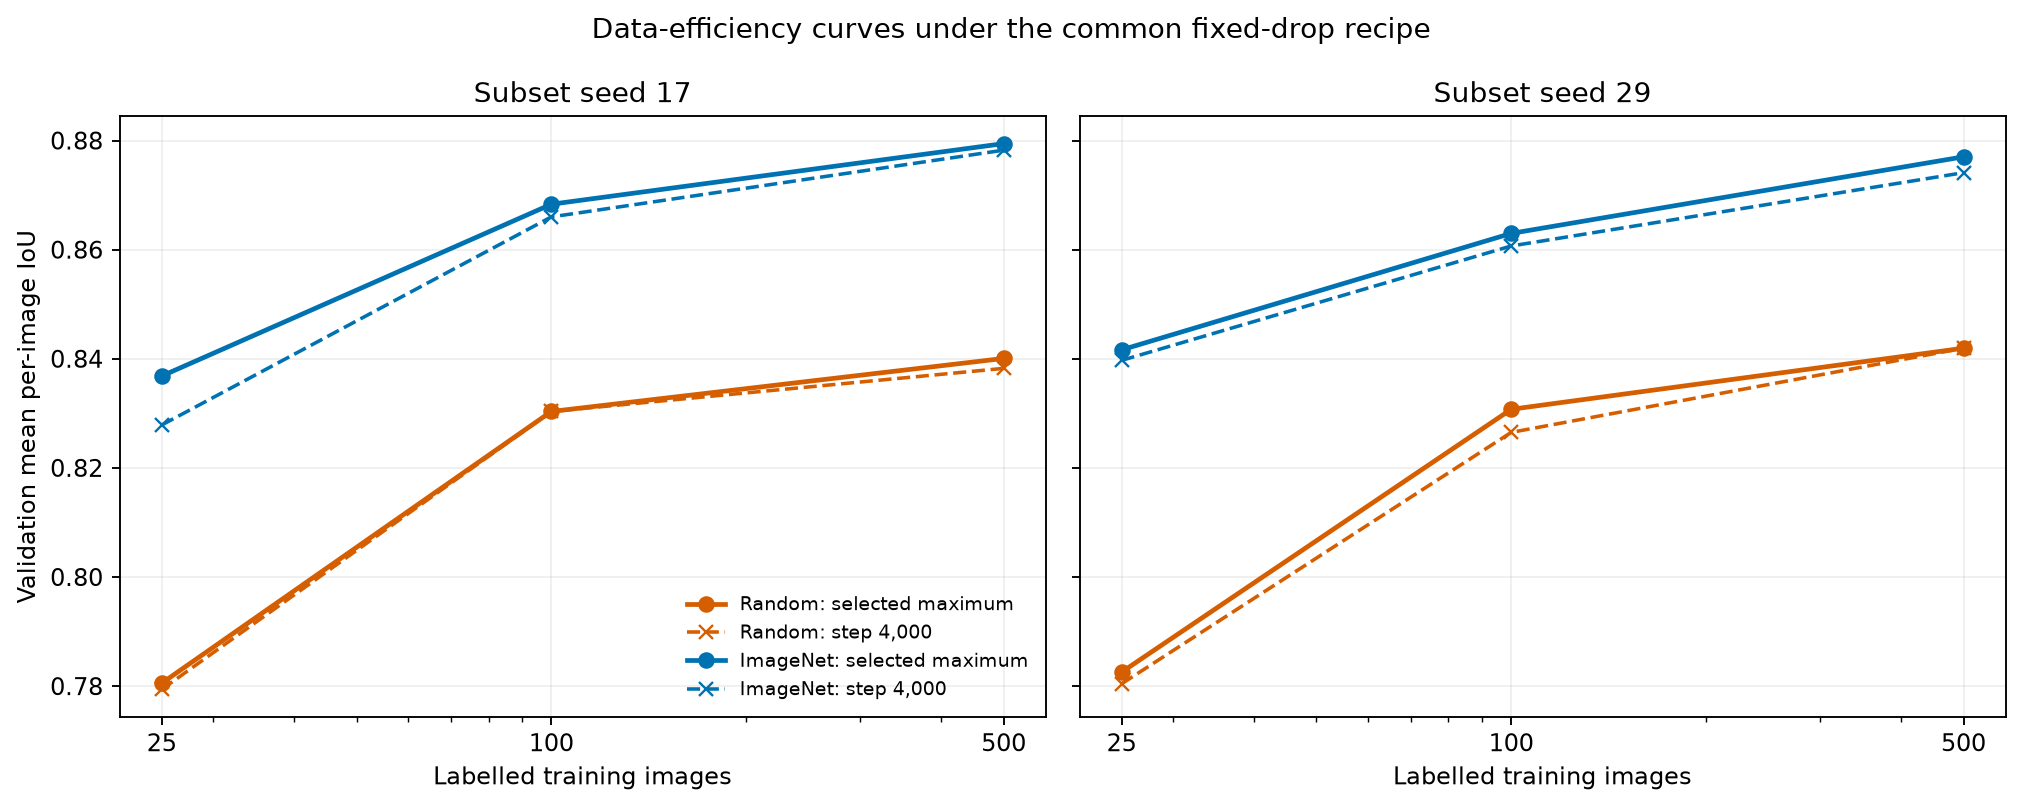

In [4]:
display(Image(filename=ROOT / 'reports/figures/data_efficiency_summary.png'))

Both repetitions show the same ordering: more labelled images improve best validation IoU, and ImageNet initialization leads at every size. Seed 17 random/ImageNet best IoU changes from 0.781/0.837 at n=25 to 0.830/0.868 at n=100 and 0.840/0.879 at n=500. Seed 29 gives 0.783/0.842, 0.831/0.863 and 0.842/0.877. The differences between subset selections are small relative to the initialization gap.

The four new Seed 29 runs required 80.1 minutes of optimization and 99.6 minutes including evaluation on MPS. Their selected steps range from 2,600 to 4,000, illustrating why a common update budget does not imply identical convergence.

## 4. Paired pretraining differences and gains from more labels

Positive paired differences mean that ImageNet initialization scores higher than random initialization within the same training subset and schedule. Size gains compare adjacent points within one initialization and one nested subset family; they are descriptive changes, not independent treatment effects.

In [5]:
paired_columns = {
    'subset_seed': 'subset seed', 'training_size': 'images',
    'imagenet_minus_random_best_iou': 'best-IoU difference',
    'imagenet_minus_random_iou_step_4000': 'endpoint-IoU difference',
    'imagenet_minus_random_dice': 'Dice difference',
    'imagenet_minus_random_ap': 'AP difference',
}
display(PAIRED[list(paired_columns)].rename(columns=paired_columns).style.format({
    'best-IoU difference': '{:+.3f}', 'endpoint-IoU difference': '{:+.3f}',
    'Dice difference': '{:+.3f}', 'AP difference': '{:+.3f}',
}))

,subset seed,images,best-IoU difference,endpoint-IoU difference,Dice difference,AP difference
0,17,25,+0.056,+0.048,+0.038,+0.021
1,17,100,+0.038,+0.036,+0.023,+0.006
2,17,500,+0.039,+0.040,+0.024,+0.013
3,29,25,+0.059,+0.059,+0.039,+0.026
4,29,100,+0.032,+0.034,+0.019,+0.005
5,29,500,+0.035,+0.032,+0.022,+0.012


In [6]:
gain_columns = {
    'subset_seed': 'subset seed', 'initialization': 'initialization',
    'size_change': 'size change', 'best_iou_gain': 'best-IoU gain',
    'endpoint_iou_gain': 'endpoint-IoU gain',
}
display(GAINS[list(gain_columns)].rename(columns=gain_columns).style.format({
    'best-IoU gain': '{:+.3f}', 'endpoint-IoU gain': '{:+.3f}',
}))

,subset seed,initialization,size change,best-IoU gain,endpoint-IoU gain
0,17,imagenet,25_to_100,+0.031,+0.038
1,17,imagenet,100_to_500,+0.011,+0.012
2,17,random,25_to_100,+0.050,+0.051
3,17,random,100_to_500,+0.010,+0.008
4,29,imagenet,25_to_100,+0.021,+0.021
5,29,imagenet,100_to_500,+0.014,+0.013
6,29,random,25_to_100,+0.048,+0.046
7,29,random,100_to_500,+0.011,+0.015


The paired ImageNet-minus-random best-IoU differences are +0.056 and +0.059 at n=25, +0.038 and +0.032 at n=100, and +0.039 and +0.035 at n=500 for seeds 17 and 29. The pretraining advantage is therefore positive and similar in both training-image selections, with the largest advantage at n=25.

Moving from 25 to 100 images adds 0.048–0.050 IoU for random initialization and 0.021–0.031 for ImageNet. The 100-to-500 gain is smaller but positive in all four comparisons (0.010–0.014). This consistent diminishing gain describes the observed validation curve; two partially overlapping repetitions are insufficient to estimate a precise population learning curve.

## 5. Training trajectories and late behavior

The upper two rows show deterministic validation IoU and loss. The lower row shows the augmented training-mode objective averaged over the preceding 100 updates; it diagnoses optimization but is not numerically interchangeable with validation loss. The vertical line marks the learning-rate change. Separate panels preserve enough resolution to inspect both subset selections.

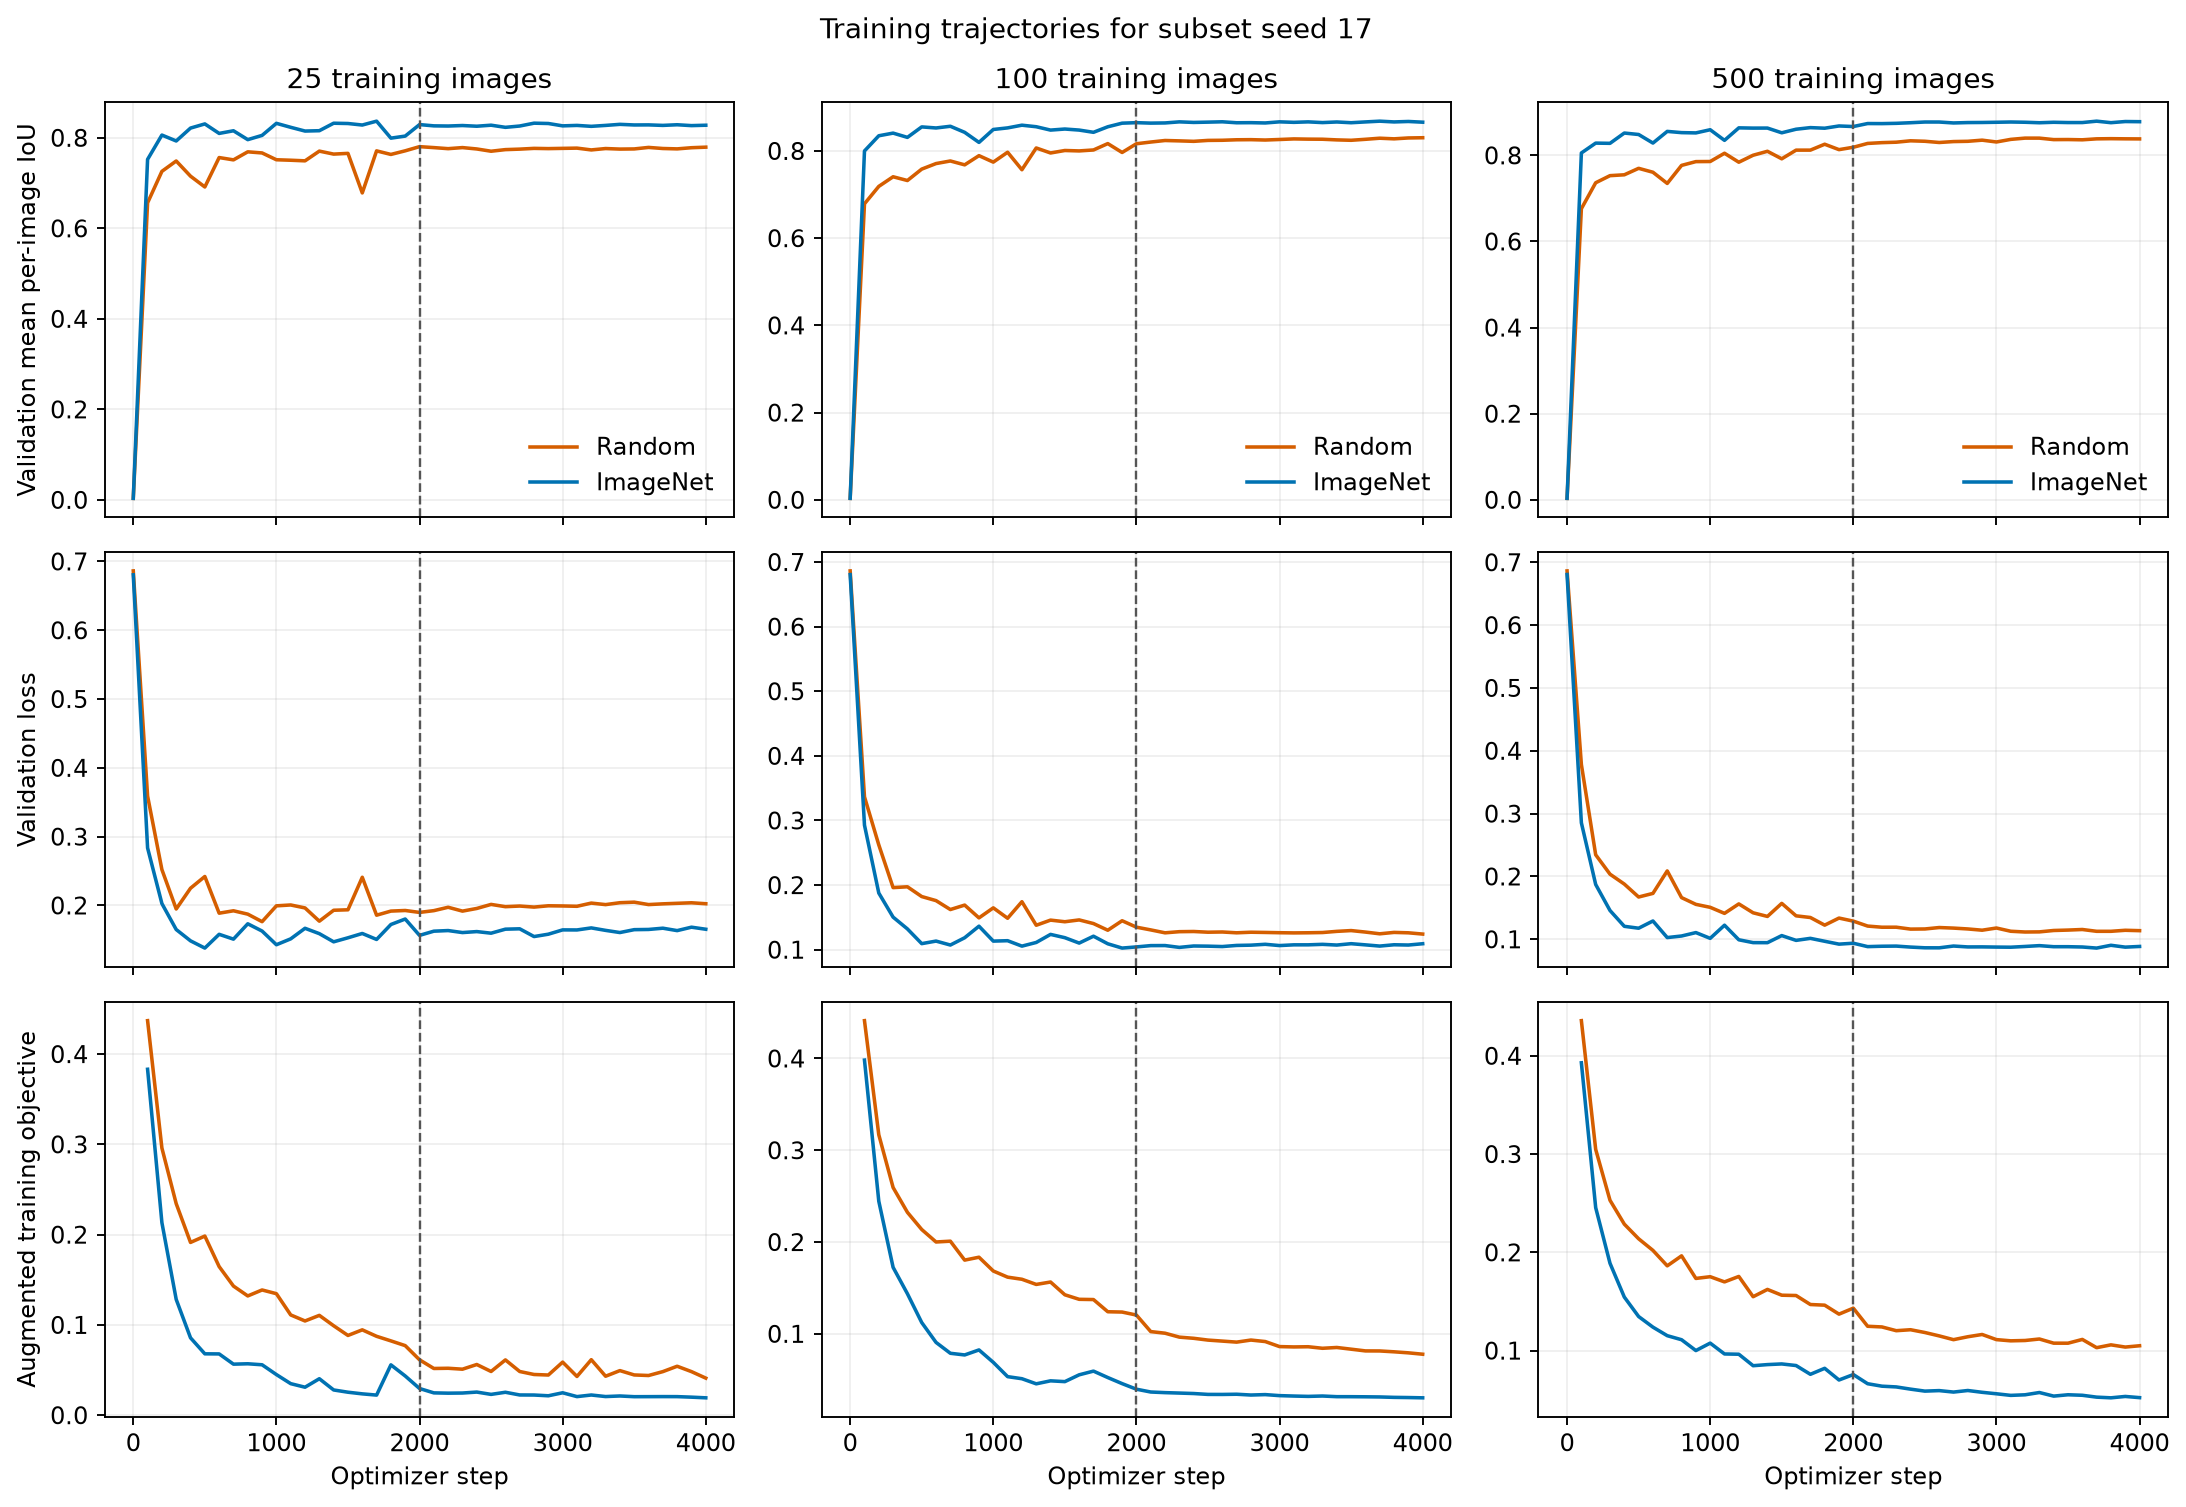

In [7]:
display(Image(filename=ROOT / 'reports/figures/data_efficiency_histories_seed17.png'))

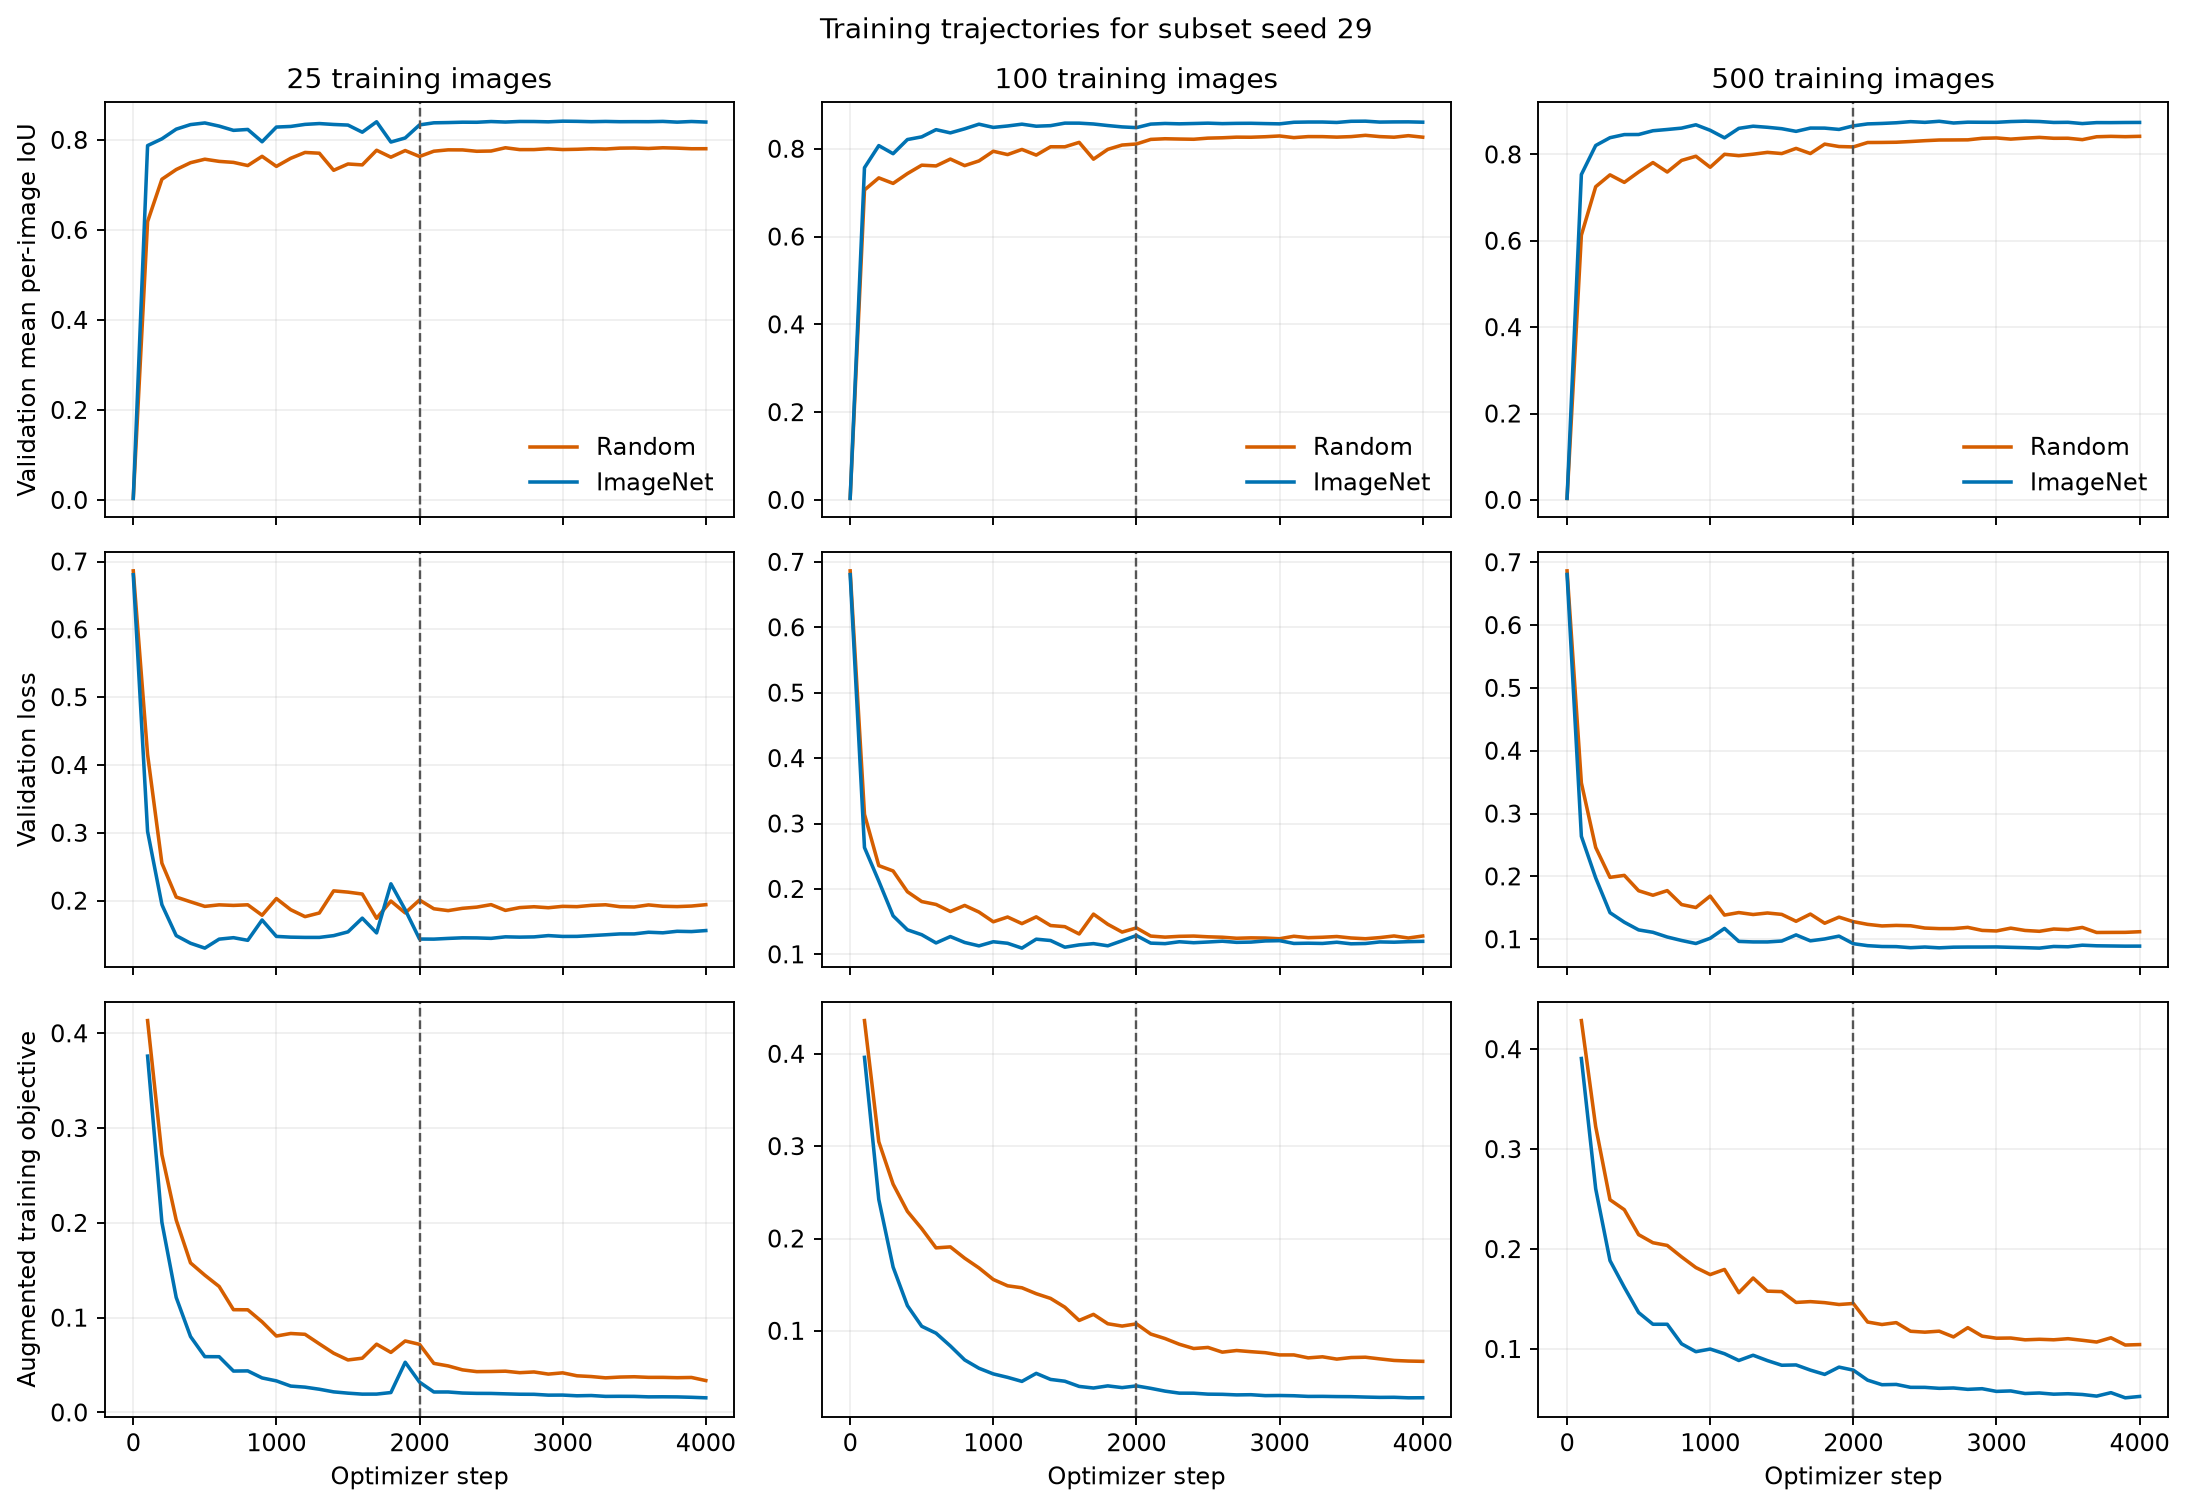

In [8]:
display(Image(filename=ROOT / 'reports/figures/data_efficiency_histories_seed29.png'))

The n=25 overfitting pattern repeats, although the selected-step timing changes. Both repetitions drive the augmented training objective very low, retain train–validation IoU gaps near 0.13–0.15, and show increasing late validation loss. Seed 29 ImageNet selects step 3,000 rather than Seed 17's step 1,700, so “early overfitting” should describe the separation between training and validation behavior rather than one universal stopping step.

At n=500, both random models continue improving after the step-2,000 rate change: their late IoU trends are +0.0054 and +0.0073 per 1,000 updates. The ImageNet models improve earlier and show much flatter late trends (+0.0017 and +0.0004). Thus the 4,000-update budget still appears limiting for random initialization at n=500, while the pretrained models are closer to a plateau.

## 6. Comparable train–validation metrics and late diagnostics

Training metrics below are recomputed at the selected checkpoint with augmentation disabled and evaluation mode enabled, matching validation preprocessing and model mode. The train-minus-validation IoU gap is descriptive because related imagery and repeated structures violate simple independence assumptions. Late trends and residual standard deviations use the same predeclared measurements from steps 2,100–4,000; residual SD measures scatter around a fitted line and is not a confidence interval.

In [9]:
evaluation_columns = {
    'subset_seed': 'seed', 'training_size': 'images', 'initialization': 'init',
    'selected_training_loss': 'train loss', 'selected_validation_loss': 'val loss',
    'selected_training_iou': 'train IoU', 'best_validation_iou': 'val IoU',
    'training_minus_validation_iou': 'IoU gap',
    'selected_training_dice': 'train Dice', 'selected_validation_dice': 'val Dice',
    'selected_training_ap': 'train AP', 'selected_validation_ap': 'val AP',
}
display(RESULTS[list(evaluation_columns)].rename(columns=evaluation_columns).style.format({
    column: '{:.3f}' for column in list(evaluation_columns.values())[3:]
}))

,seed,images,init,train loss,val loss,train IoU,val IoU,IoU gap,train Dice,val Dice,train AP,val AP
0,17,25,imagenet,0.020,0.151,0.967,0.837,0.130,0.983,0.906,0.999,0.948
1,17,25,random,0.047,0.190,0.922,0.781,0.141,0.959,0.868,0.992,0.927
2,17,100,imagenet,0.029,0.106,0.952,0.868,0.083,0.975,0.926,0.997,0.969
3,17,100,random,0.070,0.124,0.892,0.830,0.061,0.942,0.903,0.986,0.963
4,17,500,imagenet,0.049,0.086,0.923,0.879,0.044,0.959,0.933,0.990,0.982
5,17,500,random,0.103,0.112,0.843,0.840,0.003,0.911,0.909,0.969,0.970
6,29,25,imagenet,0.017,0.147,0.972,0.842,0.130,0.986,0.908,0.999,0.959
7,29,25,random,0.039,0.186,0.935,0.783,0.153,0.966,0.869,0.995,0.934
8,29,100,imagenet,0.027,0.117,0.956,0.863,0.093,0.977,0.922,0.998,0.970
9,29,100,random,0.064,0.124,0.900,0.831,0.069,0.947,0.903,0.988,0.965


In [10]:
late_columns = {
    'subset_seed': 'seed', 'training_size': 'images', 'initialization': 'init',
    'iou_trend_per_1000': 'IoU trend / 1,000',
    'iou_residual_sd': 'IoU residual SD',
    'loss_trend_per_1000': 'loss trend / 1,000',
    'loss_residual_sd': 'loss residual SD',
}
display(RESULTS[list(late_columns)].rename(columns=late_columns).style.format({
    'IoU trend / 1,000': '{:+.4f}', 'IoU residual SD': '{:.4f}',
    'loss trend / 1,000': '{:+.4f}', 'loss residual SD': '{:.4f}',
}))

,seed,images,init,"IoU trend / 1,000",IoU residual SD,"loss trend / 1,000",loss residual SD
0,17,25,imagenet,+0.0010,0.0020,+0.0025,0.0029
1,17,25,random,+0.0009,0.0020,+0.0051,0.0020
2,17,100,imagenet,+0.0010,0.0010,+0.0015,0.0011
3,17,100,random,+0.0037,0.0012,-0.0011,0.0013
4,17,500,imagenet,+0.0017,0.0011,+0.0001,0.0011
5,17,500,random,+0.0054,0.0020,-0.0036,0.0017
6,29,25,imagenet,+0.0008,0.0008,+0.0063,0.0009
7,29,25,random,+0.0030,0.0016,+0.0027,0.0019
8,29,100,imagenet,+0.0030,0.0011,+0.0002,0.0014
9,29,100,random,+0.0034,0.0016,-0.0004,0.0014


Subset choice affects individual peaks and curve details but does not reverse any main comparison. Across the two repetitions, the largest best-IoU shift for one size/initialization is 0.0054 (n=100 ImageNet), while every paired pretraining difference remains positive. The small residual SD values (0.0008–0.0020 for IoU) show that the late-window conclusions do not depend on a single isolated checkpoint, but adjacent validation measurements remain strongly dependent.

## 7. Limitations and next experiment

These are preliminary validation findings from two partially overlapping nested subset families and one repeatedly used validation region. The experiment varies training-image selection, not the complete training randomness: model construction, data order and augmentation seeds are deliberately fixed. Reusing validation for checkpoint selection and successive research decisions introduces selection bias. The shared update budget yields very different data passages and does not prove equal convergence. No confidence interval, significance claim, cross-city claim or independent test performance follows from two repetitions. The 259-image test region was absent from training, selection and qualitative analysis.

The next limited experiment should target the repeated n=25 train–validation separation. A paired weight-decay screen is the cleanest first choice because it changes one existing optimizer factor without expanding the augmentation distribution: compare the current `1e-4` with one stronger value at n=25 for both initializations and both saved subset repetitions, under the same schedule and seeds. Predeclare the value and success criterion before running it. Mild brightness/contrast augmentation is a reasonable subsequent alternative if stronger decay does not reduce late validation loss without erasing the ImageNet advantage. Neither experiment is run here.

## 8. Conclusion

The Seed 29 completion reproduces the practical conclusions of the preliminary Seed 17 curve. More labelled images improve validation IoU with diminishing gains, ImageNet initialization leads at all measured sizes, n=25 shows persistent overfitting, and n=500 random initialization is still improving late. The similarity across two training-image selections increases confidence that these patterns are not caused by one particular subset, while the shared validation geography, partial subset overlap and fixed non-subset randomness keep the evidence exploratory.